# Regressão Linear – Previsão de Salários

Este notebook implementa um modelo de regressão linear para prever o salário
de profissionais de dados com vínculo CLT, utilizando a base tratada no projeto
de análise exploratória do curso da Programaria.

> A coluna de salário foi modificada pela equipe do curso para fins didáticos.

**Estrutura do notebook:**

| Etapa | Conteúdo |
|---|---|
| 1. Preparação dos dados | Filtragem, limpeza e engenharia de atributos |
| 2. Pré-processamento | Seleção de atributos, codificação e normalização |
| 3. Treinamento | Divisão treino/teste e ajuste do modelo |
| 4. Avaliação | MSE, MAE e R² |
| 5. Interpretação | Visualização dos resultados e análise dos coeficientes |

**Bibliotecas utilizadas:** `pandas`, `scikit-learn`, `matplotlib`


---
## 1. Preparação dos dados

Antes de treinar qualquer modelo, os dados precisam estar limpos e em um formato
que o algoritmo consiga processar. Isso inclui filtrar o subconjunto relevante,
remover categorias problemáticas e transformar variáveis textuais em numéricas.


### 1.1 Carregamento da base

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_excel('/content/drive/MyDrive/PROGRAMARIA - ANÁLISE DE DADOS/analise_dados_mod7_(1).xlsx')

In [ ]:
data.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


### 1.2 Filtragem por vínculo empregatício

O modelo será treinado apenas com respondentes CLT, pois o salário de
autônomos, estagiários e outros vínculos segue dinâmicas muito diferentes,
o que prejudicaria a capacidade preditiva do modelo.


In [ ]:
data.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
data['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [ ]:
# Filtrando tudo que seja empregado clt
data = data[data['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)']

In [ ]:
data['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


### 1.3 Tratamento da coluna COR/RAÇA/ETNIA

Categorias com poucos registros ('Outra', 'Indígena', 'Prefiro não informar')
são removidas porque distorcem a média salarial do grupo e introduzem ruído
no modelo. Em seguida, criamos uma variável binária `NAO_BRANCA`:
- `1` para pessoas não brancas
- `0` para pessoas brancas

Isso permite que o modelo capture o efeito da etnia sobre o salário
sem criar múltiplas colunas dummies para cada categoria.


In [ ]:
data['COR/RACA/ETNIA'].value_counts()

,count
COR/RACA/ETNIA,
Branca,1805
Parda,661
Preta,181
Amarela,85
Prefiro não informar,16
Outra,10
Indígena,4


In [ ]:
# Vamos remover as categorias com poucos dados
# Vimos no gráfico que a categoria de outra e indígena ficaram com uma média super alta, então não queremos atrapalhar o modelo

lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']

In [ ]:
data = data[~data['COR/RACA/ETNIA'].isin(lista_retirar)]
# .isin é uma função que pega o que está dentro do parâmetro
# ~ significa contrário, ou seja nesse caso retirar

In [ ]:
# Vamos criar a coluna não branca, que recebe 0 e 1 utilizando o apply

data['NAO_BRANCA'] = data['COR/RACA/ETNIA'].apply(lambda x: 1 if x != 'Branca' else 0)
# Se for diferente de branco recebe 1 e se for igual a branco recebe 0

### 1.4 Extraindo o tempo de experiência

A coluna de experiência contém texto como 'de 1 a 2 anos' ou 'menos de 1 ano'.
Usamos `str.extract()` com uma expressão regular para capturar apenas o primeiro
número de cada resposta. O padrão `r'(\d+)'` significa:
- `\d` — qualquer dígito de 0 a 9
- `+` — um ou mais dígitos consecutivos
- `r''` — string raw, que trata a barra invertida como caractere literal

Valores nulos (respostas sem número extraível) são preenchidos com `0`.


In [ ]:
data['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?']
# Vamos pegar o primeiro valor numérico de cada tipo de resposta

,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?
1,de 3 a 4 anos
2,de 3 a 4 anos
3,de 4 a 6 anos
6,de 1 a 2 anos
7,Menos de 1 ano
...,...
4262,de 3 a 4 anos
4263,de 3 a 4 anos
4266,de 3 a 4 anos
4267,de 1 a 2 anos


In [ ]:
data['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].unique()

array(['de 3 a 4 anos', 'de 4 a 6 anos', 'de 1 a 2 anos',
       'Menos de 1 ano', 'Mais de 10 anos', 'de 7 a 10 anos',
       'Não tenho experiência na área de dados'], dtype=object)

In [ ]:
data['TEMPO_EXPERIENCIA'] = data['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')
#.str acessa a string e depois da função
# dentro do extract é oque vamos extrair
#r'(\d+)' -> r é uma string crua onde caracteres especiais são tratados diferentes
#\d é um metacaractere, que representa qualquer dígito de 0 a 9
#+ é um quantificador que indica um ou mais do que o procede. Se for 10 anos, ele pega 10
#Na prática significa um ou mais dígitos.

### 1.5 Tratando a coluna NUMERO DE FUNCIONARIOS

A coluna contém pontos como separadores de milhar (ex: '1.000') que precisam
ser removidos antes da extração numérica, para evitar que `str.extract` capture
apenas o trecho antes do ponto.


In [ ]:
data['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3000,1313
de 101 a 500,503
de 1001 a 3000,368
de 501 a 1000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [ ]:
data['NUMERO DE FUNCIONARIOS'] = data['NUMERO DE FUNCIONARIOS'].str.replace('.', '')

In [ ]:
data['NUMERO DE FUNCIONARIOS'] = data['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [ ]:
data['NUMERO DE FUNCIONARIOS'].value_counts(dropna = False)

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [ ]:
data['TEMPO_EXPERIENCIA'].value_counts(dropna = False)

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
0,127


In [ ]:
# Substituindo os nulos por 0
data['TEMPO_EXPERIENCIA'] = data['TEMPO_EXPERIENCIA'].fillna(0)

### 1.6 Criando o indicador de insatisfação salarial

A coluna de insatisfação com a empresa é textual e possui muitos nulos
(respondentes satisfeitos não preenchem). Criamos uma variável binária `INSATISFACAO`:
- `1` se o respondente mencionou 'Salário' como motivo de insatisfação
- `0` em todos os outros casos (incluindo nulos)

Usamos `.loc[]` combinado com `.notnull()` para evitar processar células vazias.


In [ ]:
data['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,69
Salário atual não corresponde ao mercado,53
Falta de oportunidade de crescimento no emprego atual,46
Falta de maturidade analítica na empresa,45
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",26
...,...
"O clima de trabalho/ambiente não é bom, Não tenho uma boa relação com meu líder/gestor, Gostaria de receber mais benefícios",1
Falta de organização nos processos internos,1
"Gostaria de receber mais benefícios, O clima de trabalho/ambiente não é bom, Falta de oportunidade de crescimento no emprego atual",1


In [ ]:
data['INSATISFACAO'] = 0

In [ ]:
# .loc Localizando na tabela
data.loc[data['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = data.loc[data['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [ ]:
data['INSATISFACAO'].value_counts()

,count
INSATISFACAO,
0,2453
1,279


### 1.7 Codificando o nível de ensino

Convertemos a coluna categórica ordinal de nível de ensino em valores numéricos,
preservando a ordem hierárquica dos graus de escolaridade:

| Valor | Categoria |
|---|---|
| 0 | Não tenho graduação formal |
| 1 | Estudante de Graduação |
| 2 | Graduação/Bacharelado |
| 3 | Pós-graduação |
| 4 | Mestrado |
| 5 | Doutorado ou PhD |
| -1 | Demais casos |


In [ ]:
data['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1024
Pós-graduação,975
Mestrado,306
Estudante de Graduação,271
Doutorado ou Phd,100
Não tenho graduação formal,52
Prefiro não informar,4


In [ ]:
data['NIVEL DE ENSINO'] = data['NIVEL DE ENSINO'].apply(lambda x: 0 if x == 'Não tenho graduação formal' else
                              1 if x == 'Estudante de Graduação' else
                              2 if x == 'Graduação/Bacharelado' else
                              3 if x == 'Pós-graduação' else
                              4 if x== 'Mestrado' else
                              5 if x== 'Doutorado ou Phd' else -1)

---
## 2. Pré-processamento

Com os atributos tratados, selecionamos as colunas que entrarão no modelo,
aplicamos codificação dummy nas variáveis categóricas restantes e
normalizamos os dados para que o algoritmo funcione com escala uniforme.


### 2.1 Seleção de atributos

Mantemos apenas as colunas relevantes para a predição do salário,
descartando identificadores, campos textuais brutos e colunas que
já foram substituídas por versões tratadas.


In [ ]:
data.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
# Seleção de atributos para o modelo
data = data[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL']]

In [ ]:
data.columns

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')

### 2.2 Codificação dummy das variáveis categóricas

`pd.get_dummies()` transforma colunas categóricas nominais em colunas binárias.
O parâmetro `drop_first=True` remove a primeira categoria de cada coluna,
evitando multicolinearidade perfeita — problema em que uma coluna pode ser
derivada exatamente das demais, o que prejudica a estimativa dos coeficientes.


In [ ]:
data = pd.get_dummies(data, columns = ['GENERO', 'REGIAO ONDE MORA', 'NOVO_NIVEL', 'SETOR'], drop_first=True)

### 2.3 Separação entre atributos e variável alvo

Em machine learning supervisionado, separamos:
- `X`: matriz de atributos (todas as colunas exceto o que queremos prever)
- `y`: variável alvo (o que o modelo deve aprender a prever — neste caso, o salário)


In [ ]:
# Antes de criar o modelo precisamos dividir o conjunto de treinamento e o conjunto de teste
# Vamos separar os atributos do nosso objetivo (salário)

X = data.drop('SALARIO', axis = 1) #Excluindo salario
y = data['SALARIO'] # Definindo o target

### 2.4 Divisão treino/teste

`train_test_split()` divide os dados em dois conjuntos:
- **Treino (80%)**: usado para o modelo aprender os padrões.
- **Teste (20%)**: usado para avaliar o desempenho em dados que o modelo nunca viu.

`random_state=42` garante que a divisão seja sempre a mesma, tornando os
resultados reproduzíveis.


In [ ]:
# importando do sklearn para dividirmos os dados treino teste
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# test_size define o tamanho em porcentagem para o conjunto teste
# random state garante que seja reproduzível
# o resultado vai ser dois conjunto de teste e um de treinamento, e dois com juntos com o alvo(target) um para teste e um para treinamento

### 2.5 Normalização com StandardScaler

Modelos lineares são sensíveis à escala dos atributos — uma variável em
milhares (salário) teria peso artificialmente maior do que uma em unidades
(anos de experiência). O `StandardScaler` transforma cada coluna para
ter média 0 e desvio padrão 1, colocando todos os atributos na mesma escala.

- `fit_transform()` no conjunto de treino: aprende a escala e já transforma.
- `transform()` no conjunto de teste: aplica a mesma escala aprendida no treino.

> Usar `fit_transform` no conjunto de teste seria um erro — causaria vazamento de
> informação (data leakage), pois a escala do teste influenciaria o modelo.


In [ ]:
#importando o standard scaler
from sklearn.preprocessing import StandardScaler
# ela padroniza as características (normaliza os dados), pois modelos assim funcionam melhor com uma escala uniforme

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

---
## 3. Treinamento do modelo

A regressão linear busca encontrar a combinação linear dos atributos que
minimiza a diferença entre os valores previstos e os valores reais.
O resultado são os **coeficientes** de cada atributo — quanto cada variável
contribui para aumentar ou diminuir o salário previsto.


In [ ]:
# importando do sklearn
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

---
## 4. Avaliação do modelo

Utilizamos três métricas para avaliar a qualidade das predições:

| Métrica | O que mede | Interpretação |
|---|---|---|
| **MSE** (Erro Quadrático Médio) | Média dos erros ao quadrado | Penaliza erros grandes; difícil de interpretar na escala original |
| **MAE** (Erro Médio Absoluto) | Média dos erros absolutos | Mesma escala do target; mais intuitivo |
| **R²** (Coeficiente de Determinação) | % da variação do target explicada pelo modelo | 0% = modelo inútil; 100% = modelo perfeito |


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# calculando o MSE. quanto menor o valor, mais preciso a predição do modelo

mse = mean_squared_error(y_test, y_pred)

In [ ]:
mse

23048733.978297204

> O MSE ficou muito alto porque os erros são elevados ao quadrado — poucos casos
> com predição muito ruim inflam essa métrica desproporcionalmente.
> Como a escala do MSE não é a mesma do salário, é difícil interpretar o resultado diretamente.
> Por isso calculamos também o MAE, que mantém a mesma escala do target.


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
mae

3298.964464206939

In [ ]:
r2 = r2_score(y_test, y_pred)

In [ ]:
r2

0.5297347873934932

> **Resultado:** R² de 0,52, MAE de ~R$ 3.291 e MSE de ~23 milhões.
>
> O modelo explica cerca de metade da variação salarial (R² = 0,52) e erra
> em média ~R$ 3.291 por predição. O MSE alto indica que existem casos com
> erros muito grandes, especialmente para salários elevados.
> Para uso em produção, o modelo precisaria de refinamento — mais atributos,
> tratamento de não-linearidades ou outro algoritmo.


---
## 5. Interpretação dos resultados

Além das métricas numéricas, visualizamos os resultados graficamente para
entender onde o modelo acerta e onde erra, e quais atributos têm mais
influência sobre as predições.


### 5.1 Valores reais vs. valores preditos

No gráfico de dispersão abaixo, pontos sobre a linha vermelha indicam predições
perfeitas. Quanto mais afastado da linha, maior o erro. A linha vermelha é
desenhada do menor ao maior valor real, representando o cenário ideal.


In [ ]:
# vamos plotar um gráfico dos valores reais VS valores preditos

import matplotlib.pyplot as plt

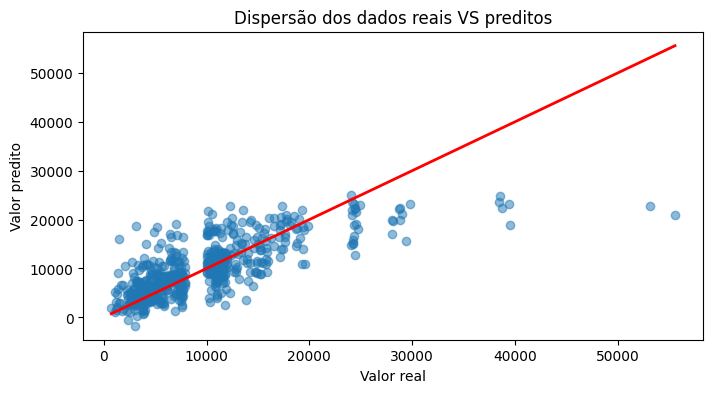

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha = 0.5) # fazendo o gráfico de dispersão dos valores
plt.xlabel('Valor real')
plt.ylabel('Valor predito')
plt.title('Dispersão dos dados reais VS preditos')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = 'red', linewidth = 2)
plt.show()

### 5.2 Coeficientes do modelo

Os coeficientes indicam o quanto cada atributo contribui para o salário previsto,
mantidos os demais constantes:
- **Coeficiente positivo**: o atributo aumenta o salário previsto.
- **Coeficiente negativo**: o atributo diminui o salário previsto.
- A linha vermelha em `x=0` separa os dois grupos.


In [ ]:
nomes_atributos = X_train.columns

In [ ]:
nomes_atributos

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul', 'NOVO_NIVEL_Pessoa Gestora', 'NOVO_NIVEL_Pleno',
       'NOVO_NIVEL_Sênior', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria'],
      dtype='object')

In [ ]:
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index = nomes_atributos)

In [ ]:
coefs = coefs.sort_values(by= 'coeficientes', ascending = False)

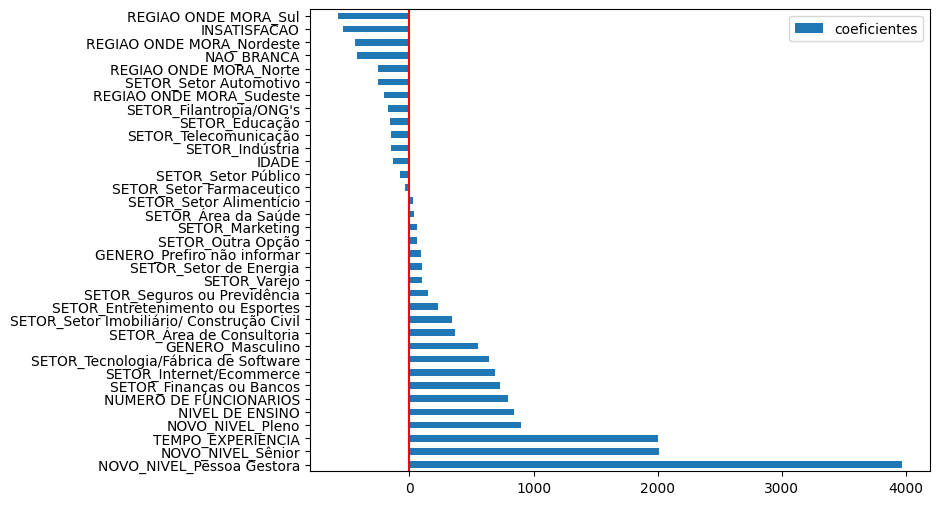

In [ ]:
coefs.plot.barh(figsize = (8,6))
plt.axvline(x=0, color = 'red')

In [ ]:
# temos que as barras antes do zero tem peso negativo para predição e as acima, um peso positivo, aumentando o valor do salário na predição

### 5.3 Reflexão sobre viés e ética

> O modelo foi treinado sobre dados reais da pesquisa, que refletem as desigualdades
> existentes no mercado de trabalho brasileiro — diferenças salariais por gênero,
> etnia e região são padrões reais presentes nos dados.
>
> Um modelo treinado sobre esses dados tende a **reproduzir esses vieses**.
> Se fosse utilizado para estimar salários em um processo seletivo ou de remuneração,
> poderia perpetuar desigualdades históricas em vez de corrigi-las.
>
> Por isso, análises de machine learning aplicadas a dados sobre pessoas exigem
> atenção cuidadosa à ética e ao impacto social das decisões tomadas com base nos resultados.
